# Notebook for creating figures for the paper

In [ ]:
import os
import sys
import json

EXPERIMENT_DIR = '..'
sys.path.append(os.path.join(EXPERIMENT_DIR, '..'))
sys.path.append(EXPERIMENT_DIR)

from utils import dataset
from torch.utils.data import DataLoader

from utils import visualization
from utils.model_building import build_and_load_trained_model

import torch, numpy as np



TRAINED_MODELS_DIR = os.path.join(EXPERIMENT_DIR, 'trained_models')
DATA_DIR = os.path.join(EXPERIMENT_DIR, '..', 'data', 'datasets')

if torch.cuda.is_available():
    torch.cuda.set_device(0)
    DEVICE = torch.cuda.current_device()
    print('Current device:', torch.cuda.get_device_name(DEVICE))
else:
    print('Failed to find GPU. Will use CPU.')
    DEVICE = 'cpu'

Current device: NVIDIA A100-SXM4-40GB


In [ ]:
from PIL import Image

def crop_rb_png(file):
    image = Image.open(file)

    # Convert to RGBA to ensure transparency handling if needed
    image = image.convert("RGBA")

    # Get the bounding box of the non-white area
    bbox = list(image.getbbox())
    bbox[0] += 134
    bbox[1] += 353
    bbox[2] -= 83
    bbox[3] -= 352
    # Crop the image using the bounding box
    cropped_image = image.crop(bbox)

    # Save the cropped image
    cropped_image.save(file)

In [2]:
# anim_sim_file = os.path.join(DATA_DIR, f'x48_y48_z32_Ra2500_Pr0.7_t0.01_snap0.125_dur1000.h5')
anim_sim_file = os.path.join(DATA_DIR, f'x48_y48_z32_Ra2500_Pr0.7_t0.01_snap0.125_dur300.h5')

ds = dataset.RBDataset(anim_sim_file, 'test', device=DEVICE, shuffle=False)
data_loader = DataLoader(ds, batch_size=200, num_workers=0, drop_last=False)

for x_stand, y_stand in data_loader:
    break

print(x_stand.shape, y_stand.shape)
y = ds.de_standardize_batch(y_stand.cpu().numpy())

torch.Size([200, 48, 48, 32, 4]) torch.Size([200, 48, 48, 32, 4])


In [ ]:
# snaps_per_sim = dataset.num_samples_per_sim(anim_sim_file, 'test')
# forecast_steps = 500
# fc_ds = dataset.RBForecastDataset(anim_sim_file, 'test', device=DEVICE, shuffle=False, 
#                             warmup_seq_length=50, 
#                             forecast_seq_length=forecast_steps)
# fc_data_loader = DataLoader(fc_ds, batch_size=1, num_workers=0, drop_last=False)
# for x_stand, y_stand in fc_data_loader:
#     break

# print(x_stand.shape, y_stand.shape)
# y = fc_ds.de_standardize_batch(y_stand.cpu().numpy())

torch.Size([1, 50, 48, 48, 32, 4]) torch.Size([1, 500, 48, 48, 32, 4])


In [3]:
override_hps = {'include_autoencoder': True, 'parallel_ops': False}
# override_hps = {}
# model = build_and_load_trained_model(TRAINED_MODELS_DIR, 'FC/D4cnn', 'parameters/03_700_000', epoch=-1, override_hps=override_hps)
modelname, trainname = 'AE/D4cnn', 'main/main1'
# model, train = 'FC/D4cnn', 'main/main2'
model = build_and_load_trained_model(TRAINED_MODELS_DIR, modelname, trainname, epoch=-1, override_hps=override_hps)
# model = build_and_load_trained_model(TRAINED_MODELS_DIR, 'FC/D4cnn', 'main/main3', epoch=-1, override_hps=override_hps)
model.to(DEVICE) 
pass

/cephfs/users/fromme/equivariant-rb-forecasting/experiments/figures/../utils/training.py:257: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(file_path

Loaded state at epoch 83 with an early stop count of 0.


In [4]:
from utils import visualization

# autoencoder
# start = 400
# pred_stand = model(y_stand[0,start:start+100].to(DEVICE))
pred_stand = model(y_stand[0:20].to(DEVICE))
enc_stand = model.encode(y_stand[0:20].to(DEVICE))

# forecaster
# pred_stand = []
# for p_stand in model.forward_gen(x_stand, steps=500):
#     pred_stand.append(p_stand.cpu().detach())
# pred_stand = torch.stack(pred_stand, dim=1)

pred_stand = pred_stand.cpu().detach().numpy()

# remove standardization
y = ds.de_standardize_batch(y_stand.cpu().numpy())
pred = ds.de_standardize_batch(pred_stand)

pred.shape

(20, 48, 48, 32, 4)

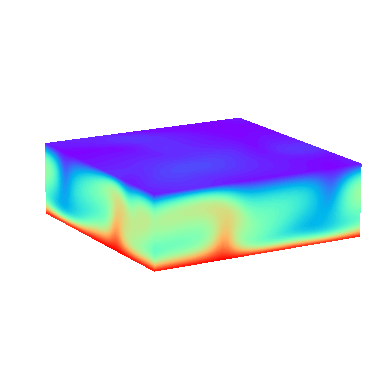

In [22]:
from matplotlib import pyplot as plt
fig = plt.figure()
    
ax1 = plt.subplot(1,1,1, projection='3d')
plt.axis('off')

# diff = y-pred

i = 1
# visualization.plot_cube_faces(diff[0, i-1, :, :, :, 0], ax1, contour_levels=100, show_back_faces=False, cmap='RdBu')
visualization.plot_cube_faces(y[i-1, :, :, :, 0], ax1, contour_levels=100, show_back_faces=False)
ax1.set_aspect('equal', adjustable='box')
ax1.view_init(elev=15, azim=-30)

file = f"./3D-RB-snapshots/{modelname.replace('/', '')}_{trainname.split('/')[1]}"
# file = f'./3D-RB-snapshots/test.png'

# snaps = list(range(0, 51, 5)) + list(range(100, 501, 100))
# np.save(f'{file}.npy', pred[:, :, :, :, :, 0])
# np.save(f'{file}_y.npy', y[:, :, :, :, :, 0])
# np.save(f'./3D-RB-snapshots/y.npy', y[0, :, :, :, :, 0])

file = './3D-RB-snapshots/x1'
plt.savefig(f'{file}.png', transparent=True, dpi=300, bbox_inches = 'tight')
# crop_rb_png(f'{file}.png')

In [26]:
ae_out_stand = model.autoencoder(y_stand[0,[0]].to(DEVICE)).detach().cpu()
ae_out = fc_ds.de_standardize_batch(ae_out_stand)
file = f"./3D-RB-snapshots/{modelname.replace('/', '')}_{trainname.split('/')[1]}"
file = file.replace('FC', 'AE')
np.save(f'{file}.npy', ae_out[:, :, :, :, 0])

In [29]:
import glob
ys = []
for path in glob.glob('./3D-RB-snapshots/*_*_y.npy'):
    ys.append(np.load(path))
    
for y in ys[1:]:
    assert np.isclose(y, ys[0]).all()
    
import torch
for path in sorted(glob.glob('./3D-RB-snapshots/FC*_main[1-3].npy')):
    pred = np.load(path)
    pred_stand = fc_ds.standardize_batch(np.repeat(pred[...,np.newaxis], 4, -1))[..., 0]
    y_stand = fc_ds.standardize_batch(np.repeat(y[...,np.newaxis], 4, -1))[..., 0]
    l = torch.nn.functional.mse_loss(torch.Tensor(pred_stand[-1]), torch.Tensor(y_stand[-1])).sqrt()
    print(path, l)

/tmp/ipykernel_2468335/517307207.py:14: UserWarning: Using a target size (torch.Size([48, 48, 32])) that is different to the input size (torch.Size([500, 48, 48, 32])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  l = torch.nn.functional.mse_loss(torch.Tensor(pred_stand[-1]), torch.Tensor(y_stand[-1])).sqrt()


./3D-RB-snapshots/FC3Dcnn_main1.npy tensor(0.9822)
./3D-RB-snapshots/FC3Dcnn_main2.npy tensor(0.9961)
./3D-RB-snapshots/FC3Dcnn_main3.npy tensor(1.5742)
./3D-RB-snapshots/FCD4cnn_main1.npy tensor(0.2557)
./3D-RB-snapshots/FCD4cnn_main2.npy tensor(0.1924)
./3D-RB-snapshots/FCD4cnn_main3.npy tensor(0.3631)


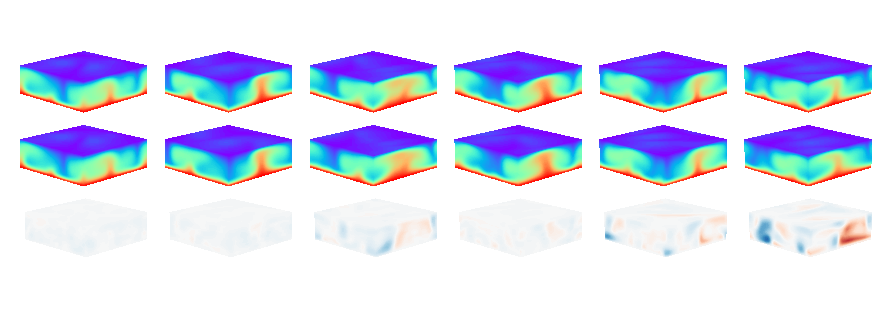

In [102]:
import sys
import os
EXPERIMENT_DIR = '..'
sys.path.append(os.path.join(EXPERIMENT_DIR, '..'))
sys.path.append(EXPERIMENT_DIR)
import numpy as np
from utils import visualization
from matplotlib import pyplot as plt


# data
d4 = np.load('./3D-RB-snapshots/FCD4cnn_main3.npy')
d4_ae = np.load('./3D-RB-snapshots/AED4cnn_main3.npy')
baseline = np.load('./3D-RB-snapshots/FC3Dcnn_main1.npy')
baseline_ae = np.load('./3D-RB-snapshots/AE3Dcnn_main1.npy')
d4_y = np.load('./3D-RB-snapshots/FCD4cnn_main3_y.npy')
baseline_y = np.load('./3D-RB-snapshots/FC3Dcnn_main1_y.npy')

assert np.isclose(d4_y, baseline_y).all()

y = d4_y

d4[0] = d4_ae
baseline[0] = baseline_ae

diff_d4 = y-d4
diff_baseline = y-baseline

#######################
    
fig = plt.figure(figsize=(8, 3))
fig.patch.set_facecolor('none')

# snaps = list(range(0, 5, 5))
snaps = np.array([1, 100, 200, 300, 400, 500])-1

rb_clims = (min(y[snaps].min(), d4[snaps].min(),),
            max(y[snaps].max(), d4[snaps].max(),))
diff_clims = (diff_d4[snaps].min(), diff_d4[snaps].max())
# rb_clims = (min(y[snaps].min(), d4[snaps].min(), baseline[snaps].min()),
#             max(y[snaps].max(), d4[snaps].max(), baseline[snaps].max()))
# diff_clims = (min(diff_d4[snaps].min(), diff_baseline[snaps].min()),
#             max(diff_d4[snaps].max(), diff_baseline[snaps].max()))

rb_kwargs = {'cmap': 'rainbow', 'vmin': rb_clims[0], 'vmax': rb_clims[1]}
diff_kwargs = {'cmap': 'RdBu', 'vmin': diff_clims[0], 'vmax': diff_clims[1]}
datas = [(y, rb_kwargs), (d4, rb_kwargs), (diff_d4, diff_kwargs), ] #(baseline, rb_kwargs), (diff_baseline, diff_kwargs)]

plt.subplots_adjust(hspace=0, wspace=0)

for i, (data, kwargs) in enumerate(datas):
    for j, snap in enumerate(snaps):

        ax = plt.subplot(5, len(snaps), i*len(snaps)+j+1, projection='3d')
        ax.set_facecolor('none')
        plt.axis('off')
        
        visualization.plot_cube_faces(data[snap, :, :, :], ax, contour_levels=100, show_back_faces=False, **kwargs)
        ax.set_aspect('equal', adjustable='box')
        ax.view_init(elev=15, azim=-45)
        
fig.tight_layout(pad=-5)
plt.savefig(f'./3D-RB-snapshots/grid.png', transparent=False, dpi=800, bbox_inches = 'tight')        

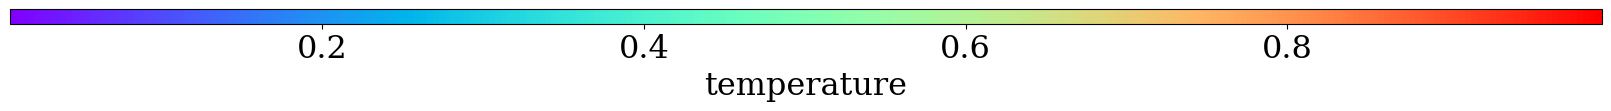

In [142]:
import matplotlib.pyplot as plt
import matplotlib as mpl

fig, ax = plt.subplots(figsize=(16, 1), layout='constrained')

norm = mpl.colors.Normalize(vmin=rb_clims[0], vmax=rb_clims[1])

cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap='rainbow'),
             cax=ax, orientation='horizontal', label='temperature', shrink=0.05, fraction=0.1, )
cbar.ax.tick_params(labelsize=23)
cbar.set_label('temperature', size=23)
plt.savefig(f'./3D-RB-snapshots/cbar_temp.pdf', transparent=False, dpi=800, bbox_inches = 'tight')        

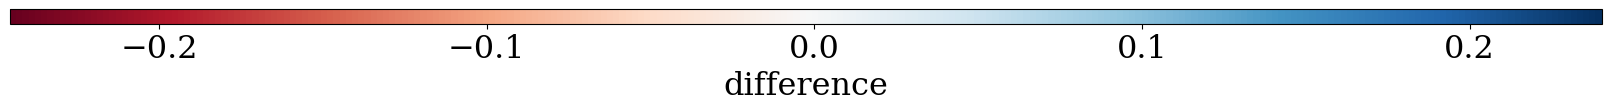

In [143]:
import matplotlib.pyplot as plt
import matplotlib as mpl

fig, ax = plt.subplots(figsize=(16, 1), layout='constrained')

norm = mpl.colors.Normalize(vmin=diff_clims[0], vmax=diff_clims[1])

cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap='RdBu'),
             cax=ax, orientation='horizontal', label='difference', shrink=0.05, fraction=0.1, )
cbar.ax.tick_params(labelsize=23)
cbar.set_label('difference', size=23)
plt.savefig(f'./3D-RB-snapshots/cbar_diff.pdf', transparent=False, dpi=800, bbox_inches = 'tight')        

# Computing Overall Training time

In [ ]:
# without hp search and testing
no_hp_search = True
autoencoder = True
forecaster = True

excluded = ['3D-D4cnn', '/cnn/', 'FC/3Dcnn/01', 'FC/3Dcnn/05', 'FC/3Dcnn/07', 'FC/D4cnn/01',
            'FC/D4cnn/05', 'FC/D4cnn/07', 'test', 'hp_search', 'FC/3Dcnn/main', 'FC/D4cnn/main',
            'FC/3Dcnn/samples', 'FC/D4cnn/samples']
excluded = ['FC/3Dcnn/main', 'FC/D4cnn/main', 'peephole']

total_training_time = 0
n = 0
import glob
for path in glob.glob('../trained_models/**/log.json', recursive=True):
    if no_hp_search:
        cont = False
        for s in excluded:
            if s in path:
                cont = True
                break
        if cont: continue
    if not autoencoder and 'AE' in path:
        continue
    if not forecaster and 'FC' in path:
        continue
    with open(path) as f:
        log = json.load(f)
        total_training_time += sum(log['epoch_duration'])
        n += 1

hours = total_training_time/60/60
days = hours/24
print(f'{hours:.2f} hours or {days:.2f} days')
print(n, 'trainings')

# Result Figures

In [42]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

In [43]:
def create_df(x_baseline, x_d4, y_baseline, y_d4, name):
    x = x_baseline + x_d4
    vals = y_baseline + y_d4

    labels = ['baseline']*len(x_baseline) + ['$\mathbf{D_4}$-steerable']*len(x_d4)

    df = pd.DataFrame(zip(x, vals, labels), columns = [name, 'RMSE', 'model'])
    return df

def plot_df(df, x_var, x_label=None, scale_x=0, y_label=True, legend=True, size_multiplier=1, legend_size_multiplier=1,
            x_ticks=None, y_ticks=None, grid=False, fontweight=600):
    # plt.figure(figsize = (4,4))

    ax = sns.lineplot(data = df, x = x_var, y = 'RMSE', hue = 'model', lw = 2.5*size_multiplier,
                    style='model', markers = ['o', 'o'], dashes = False, markersize = 8*size_multiplier ,
                    palette = ['gray', 'firebrick'], legend=legend)

    for axis in ['bottom', 'left']:
        ax.spines[axis].set_linewidth(2.5*size_multiplier)
        ax.spines[axis].set_color('0.2')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.tick_params(width = 2.5*size_multiplier, color = '0.2')

    plt.xticks(x_ticks, fontweight=fontweight, size = 14*size_multiplier, color = '0.2')
    plt.yticks(y_ticks, fontweight=fontweight, size = 14*size_multiplier, color = '0.2')
    
    if not x_label:
        x_label = x_var
    if scale_x != 0:
        x_label += ' ($\mathbf{10^'+str(scale_x)+'}$)'
    plt.xlabel(x_label)
    
    if not y_label:
        plt.ylabel('')

    ax.set_xlabel(ax.get_xlabel(), fontweight=fontweight, fontsize = 14*size_multiplier, color = '0.2')
    ax.set_ylabel(ax.get_ylabel(), fontweight=fontweight, fontsize = 14*size_multiplier, color = '0.2')
    
    # plt.xticks(ticks=np.arange(0, 12*10**6+1, 2ticks_x = ticker.FuncFormatter(lambda x, pos: '{0:g}'.format(x/scale_x))
    ticks_x = mpl.ticker.FuncFormatter(lambda x, pos: '{0:g}'.format(x/(10**scale_x)))
    ax.xaxis.set_major_formatter(ticks_x)
    
    if grid:
        plt.grid(axis='y')    

    plt.legend(frameon = False, prop = {'weight':600, 'size':14*legend_size_multiplier}, labelcolor = '0.2')
    
    return ax

def save_fig(x_var, ax):
    plt.savefig(f'./plots/{x_var}.pdf', bbox_inches = 'tight', dpi = 250, facecolor = ax.get_facecolor())

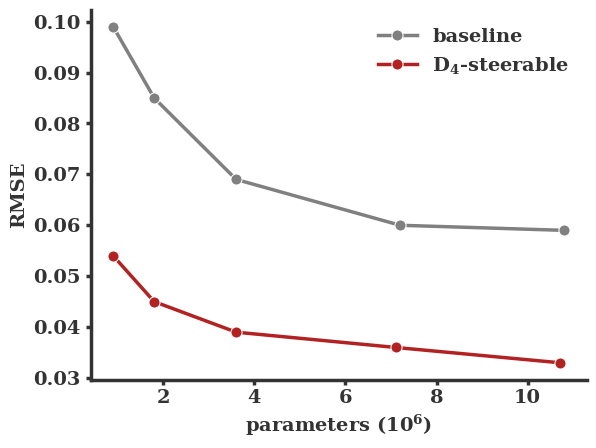

In [45]:
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "dejavuserif"

rmse_baseline_params = [0.099, 0.085, 0.069, 0.060, 0.059]
rmse_d4_params = [0.054, 0.045, 0.039, 0.036, 0.033]

params_baseline = [0.9*10**6, 1.8*10**6, 3.6*10**6, 7.2*10**6, 10.8*10**6]
params_d4 = [0.9*10**6, 1.8*10**6, 3.6*10**6, 7.1*10**6, 10.7*10**6]

df_params = create_df(x_baseline=params_baseline, x_d4=params_d4, y_baseline=rmse_baseline_params, y_d4=rmse_d4_params, name='parameters')
ax = plot_df(df_params, x_var='parameters', scale_x=6, size_multiplier=1)
# save_fig('parameters', ax)

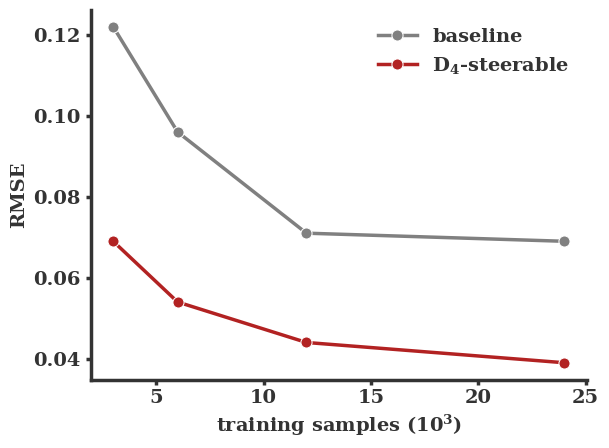

In [46]:
rmse_baseline_samples = [0.122, 0.096, 0.071, 0.069]
rmse_d4_samples = [0.069, 0.054, 0.044, 0.039]

samples_baseline = [3000, 6000, 12000, 24000]
samples_d4 = samples_baseline

df_samples = create_df(x_baseline=samples_baseline, x_d4=samples_d4, y_baseline=rmse_baseline_samples, y_d4=rmse_d4_samples, name='samples')
ax = plot_df(df_samples, x_var='samples', x_label='training samples', scale_x=3)
save_fig('samples', ax)

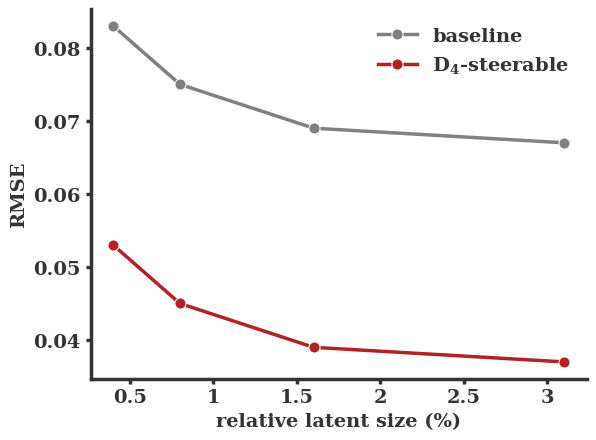

In [47]:
rmse_baseline_latent = [0.083, 0.075, 0.069, 0.067]
rmse_d4_latent = [0.053, 0.045, 0.039, 0.037]

latent_baseline = [0.4, 0.8, 1.6, 3.1]
latent_d4 = latent_baseline

df_latent = create_df(x_baseline=latent_baseline, x_d4=latent_d4, y_baseline=rmse_baseline_latent, y_d4=rmse_d4_latent, name='latent size')
ax = plot_df(df_latent, x_var='latent size', x_label='relative latent size (%)', scale_x=0)
save_fig('latent size', ax)

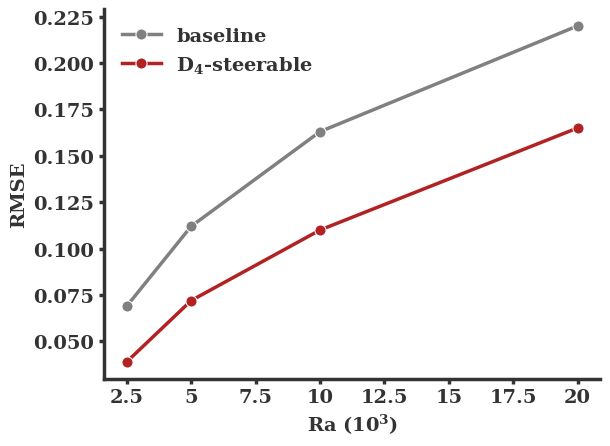

In [79]:
rmse_baseline_ra = [0.069, 0.112, 0.163, 0.220]
rmse_d4_ra = [0.039, 0.072, 0.110, 0.165]

ra_baseline = [2500, 5000, 10000, 20000]
ra_d4 = ra_baseline

df_ra = create_df(x_baseline=ra_baseline, x_d4=ra_d4, y_baseline=rmse_baseline_ra, y_d4=rmse_d4_ra, name='$\mathbf{Ra}$')
ax = plot_df(df_ra, x_var='$\mathbf{Ra}$', scale_x=3)
save_fig('latent_size', ax)

/tmp/ipykernel_2529538/1686424123.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon = False, prop = {'weight':600, 'size':14*legend_size_multiplier}, labelcolor = '0.2')
/tmp/ipykernel_2529538/1686424123.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon = False, prop = {'weight':600, 'size':14*legend_size_multiplier}, labelcolor = '0.2')
/tmp/ipykernel_2529538/1686424123.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon = False, prop = {'weight':600, 'size':14*legend_size_multiplier}, labelcolor = '0.2')


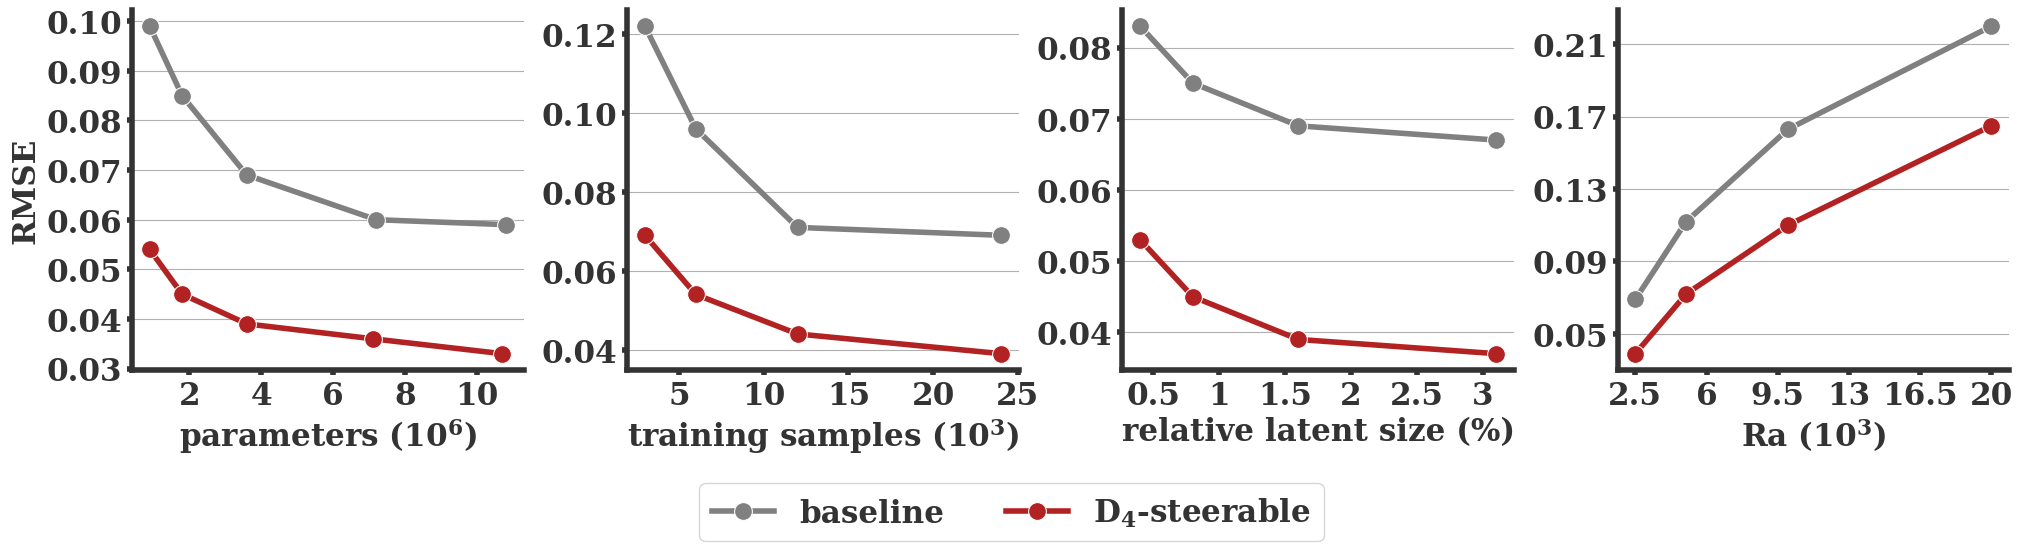

In [ ]:
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "dejavuserif"

size_multiplier = 1.6
legend_size_multiplier = 1.6
tight_layout = True
legend = 1
grid = True
fontweight = 600

fig = plt.figure(figsize=(20,5.5), constrained_layout=False)

ax1 = fig.add_subplot(1, 4, 1)
plot_df(df_params, x_var='parameters', scale_x=6, legend=legend==1, size_multiplier=size_multiplier,
        legend_size_multiplier=legend_size_multiplier, grid=grid, fontweight=fontweight)

ax2 = fig.add_subplot(1, 4, 2, sharey=None)
plot_df(df_samples, x_var='samples', x_label='training samples', scale_x=3, y_label=False, legend=legend==2, size_multiplier=size_multiplier,
        legend_size_multiplier=legend_size_multiplier, grid=grid, fontweight=fontweight)

ax3 = fig.add_subplot(1, 4, 3, sharey=None)
plot_df(df_latent, x_var='latent size', x_label='relative latent size (%)', scale_x=0, y_label=False, legend=legend==3,
        size_multiplier=size_multiplier, legend_size_multiplier=legend_size_multiplier, grid=grid, fontweight=fontweight)

ax4 = fig.add_subplot(1, 4, 4, sharey=None)
ax = plot_df(df_ra, x_var='Ra', scale_x=3, y_label=False, legend=legend==4, size_multiplier=size_multiplier,
        legend_size_multiplier=legend_size_multiplier, grid=grid,
        y_ticks=[0.21, 0.17, 0.13, 0.09, 0.05], x_ticks=[2500, 6000, 9500, 13000, 16500, 20000], fontweight=fontweight)

if tight_layout:
    fig.tight_layout(pad=-0.2)
    
fig.subplots_adjust(bottom=0.35)
fig.legend(frameon = True, prop = {'weight':fontweight, 'size':14*legend_size_multiplier}, labelcolor = '0.2',
           loc="lower center", ncol=2)

   
ax1.get_legend().remove()
    
save_fig('small', ax)

/tmp/ipykernel_1239057/873508557.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon = False, prop = {'weight':'bold', 'size':14*legend_size_multiplier}, labelcolor = '0.2')
/tmp/ipykernel_1239057/873508557.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon = False, prop = {'weight':'bold', 'size':14*legend_size_multiplier}, labelcolor = '0.2')
/tmp/ipykernel_1239057/873508557.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon = False, prop = {'weight':'bold', 'size':14*legend_size_multiplier}, labelcolor = '0.2')


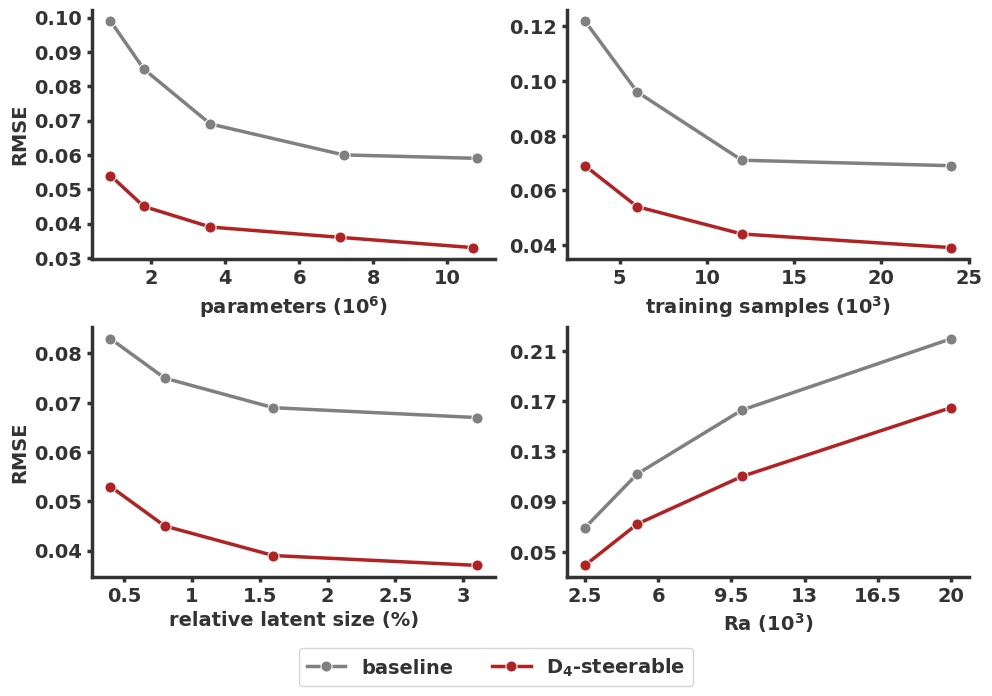

In [129]:
size_multiplier = 1
legend_size_multiplier = 1
tight_layout = True
legend = 1
grid = False

fig = plt.figure(figsize=(10,7), constrained_layout=False)

ax1 = fig.add_subplot(2, 2, 1)
plot_df(df_params, x_var='parameters', scale_x=6, legend=legend==1, size_multiplier=size_multiplier,
        legend_size_multiplier=legend_size_multiplier, grid=grid)

ax2 = fig.add_subplot(2, 2, 2, sharey=None)
plot_df(df_samples, x_var='samples', x_label='training samples', scale_x=3, y_label=False, legend=legend==2, size_multiplier=size_multiplier,
        legend_size_multiplier=legend_size_multiplier, grid=grid)

ax3 = fig.add_subplot(2, 2, 3, sharey=None)
plot_df(df_latent, x_var='latent size', x_label='relative latent size (%)', scale_x=0, y_label=True, legend=legend==3,
        size_multiplier=size_multiplier, legend_size_multiplier=legend_size_multiplier, grid=grid)

ax4 = fig.add_subplot(2, 2, 4, sharey=None)
ax = plot_df(df_ra, x_var='Ra', scale_x=3, y_label=False, legend=legend==4, size_multiplier=size_multiplier,
        legend_size_multiplier=legend_size_multiplier, grid=grid,
        y_ticks=[0.21, 0.17, 0.13, 0.09, 0.05], x_ticks=[2500, 6000, 9500, 13000, 16500, 20000])

if tight_layout:
    fig.tight_layout(pad=1)
    
fig.subplots_adjust(bottom=0.17)
fig.legend(frameon = True, prop = {'weight':'bold', 'size':14*legend_size_multiplier}, labelcolor = '0.2',
           loc="lower center", ncol=2)


ax1.get_legend().remove()
    
save_fig('large', ax)

In [64]:
import matplotlib.pyplot as plt
import json
import numpy as np
import os
from collections import defaultdict
import matplotlib as mpl

def plot_autoregressive_performance(results_dir: str, model_names: str | list, train_names: str | list, metric: str,
                                    show_std: bool = False, show_bounds = False, median: bool = True, group_same_model: bool = False,
                                    size_multiplier: float = 1, legend_size_multiplier: float = 1, fontweight='normal',
                                    x_ticks=None, y_ticks=None, scale_x=0, colors=defaultdict(lambda: 'gray'), labels=None):
    
    
    if type(model_names) == str: model_names = [model_names]
    if type(train_names) == str: train_names = [train_names]
    
    fig = plt.figure(figsize=(8, 5))
    fig, ax = plt.subplots()
    
    performances = defaultdict(list)
    performances_std = defaultdict(list)
    performances_lower = defaultdict(list)
    performances_upper = defaultdict(list)
    
    for model_name, train_name in zip(model_names, train_names):
        results_file = os.path.join(results_dir, model_name, train_name, 'autoregressive_performance.json')
        with open(results_file, 'r') as f:
            results = json.load(f)
            
        median_suffix = '_median' if median else ''
        key = model_name if group_same_model else f'{model_name}/{train_name}'
        
        performances[key].append(np.array(results[metric+median_suffix]))
        performances_lower[key].append(np.array(results[f'{metric}_lower']))
        performances_upper[key].append(np.array(results[f'{metric}_upper']))
        if show_std:
            performances_std[key].append(np.array(results[f'{metric}_std']))
        
    for key in sorted(performances.keys()):
        x = range(1, len(performances[key][0])+1)
        # ax = sns.lineplot(data = df, x = x_var, y = 'RMSE', hue = 'model', lw = 2.5*size_multiplier,
        #             style='model', markers = ['o', 'o'], dashes = False, markersize = 8*size_multiplier ,
        #             palette = ['gray', 'firebrick'], legend=legend)
        label = f'{key} - test' if not labels else labels[key]
        test_line, = plt.plot(x, np.mean(performances[key], axis=0), label=label, color=colors[key], lw=2.5*size_multiplier)
        if show_bounds:
            ax.fill_between(x, np.mean(performances_lower[key], axis=0), np.mean(performances_upper[key], axis=0), 
                            color=test_line.get_color(), alpha=0.2)
        
        if show_std:
            perf = np.mean(performances[key], axis=0)
            std = np.mean(performances_std[key], axis=0)
            ax.fill_between(x, perf-std, perf+std, 
                            color=test_line.get_color(), alpha=0.2, lw=1*size_multiplier)
    
    plt.ylabel(metric.upper())
    plt.xlabel('autoregressive steps')
    plt.legend()
    plt.grid(axis='y')
    
    
    for axis in ['bottom', 'left']:
        ax.spines[axis].set_linewidth(2*size_multiplier)
        ax.spines[axis].set_color('0.2')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.tick_params(width = 2.5*size_multiplier, color = '0.2')


    plt.xticks(x_ticks, size = 14*size_multiplier, weight = fontweight, color = '0.2')
    plt.yticks(y_ticks, size = 14*size_multiplier, weight = fontweight, color = '0.2')

    ax.set_xlabel(ax.get_xlabel(), fontsize = 14*size_multiplier, weight = fontweight, color = '0.2')
    ax.set_ylabel(ax.get_ylabel(), fontsize = 14*size_multiplier, weight = fontweight, color = '0.2')
    
    # plt.xticks(ticks=np.arange(0, 12*10**6+1, 2ticks_x = ticker.FuncFormatter(lambda x, pos: '{0:g}'.format(x/scale_x))
    ticks_x = mpl.ticker.FuncFormatter(lambda x, pos: '{0:g}'.format(x/(10**scale_x)))
    ax.xaxis.set_major_formatter(ticks_x)
    

    plt.legend(frameon = False, prop = {'weight':fontweight, 'size':14*legend_size_multiplier}, labelcolor = '0.2')
    
    return ax

<Figure size 800x500 with 0 Axes>

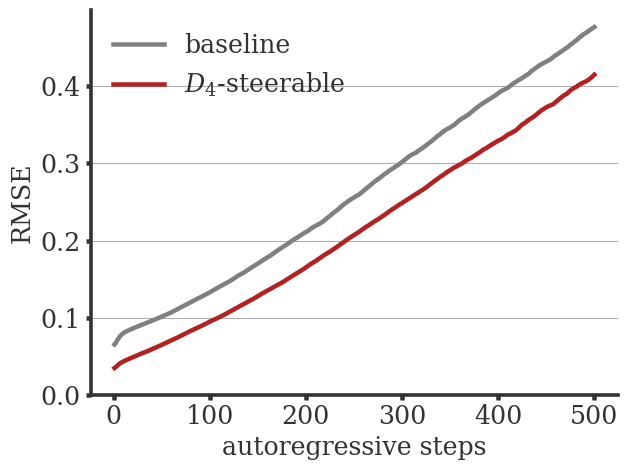

In [154]:
size_multiplier = 1.3
legend_size_multiplier = 1.3
tight_layout = True
fontweight = 'normal'

x_ticks = None
y_ticks=None


model_names = ['FC/D4cnn_save'] * 3 + ['FC/3Dcnn_save']*3
train_names = ['parameters/03_700_000', 'parameters/03_700_000_2', 'parameters/03_700_000_3'] * 2
colors = {'FC/D4cnn_save': 'firebrick', 'FC/3Dcnn_save': 'gray'}
labels = {'FC/D4cnn_save': '$\mathbf{D_4}$-steerable' if fontweight == 'bold' else '$D_4$-steerable', 
          'FC/3Dcnn_save': 'baseline'}


ax = plot_autoregressive_performance('../results', model_names=model_names, train_names=train_names, metric='rmse', show_std=False, group_same_model=True, size_multiplier=size_multiplier, legend_size_multiplier=legend_size_multiplier, x_ticks=x_ticks, y_ticks=y_ticks, 
                                colors=colors, labels=labels, median=True, show_bounds=False, fontweight=fontweight)
if tight_layout:
    plt.tight_layout()
    
plt.ylim(bottom=0)

save_fig('autoregressive_performance_mean', ax)